# Chapter 260 — Project: Monte Carlo π
### Part VIII: Probability — Project Chapter

## 0. Overview

**Problem statement:** Estimate the mathematical constant $\pi$ using random sampling alone, with no formula that references $\pi$ directly. Then build a full convergence analysis showing the estimate improves at rate $O(1/\sqrt{N})$, construct confidence intervals, apply variance reduction, and compare sampling strategies.

**Concepts from this Part:**
- Monte Carlo integration (ch256): geometric probability = area ratio
- Law of Large Numbers (ch255): convergence guarantee
- Central Limit Theorem (ch254): basis for confidence intervals
- Variance reduction via control variates (ch256, ch259)
- Simulation techniques (ch259): quasi-random (low-discrepancy) sequences

**Expected output:** A complete π estimation system with visualization, error analysis, and quasi-random acceleration.

**Difficulty:** Intermediate | **Estimated time:** 45–60 minutes

## 1. Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy import stats

rng = np.random.default_rng(42)

TRUE_PI = np.pi
print(f"True π = {TRUE_PI:.15f}")
print()
print("Project structure:")
print("  Stage 1 — Geometric estimation (circle-in-square)")
print("  Stage 2 — Convergence analysis with confidence intervals")
print("  Stage 3 — Variance reduction via stratified sampling")
print("  Stage 4 — Quasi-random (Halton sequence) comparison")
print("  Stage 5 — Results & visualization")

True π = 3.141592653589793

Project structure:
  Stage 1 — Geometric estimation (circle-in-square)
  Stage 2 — Convergence analysis with confidence intervals
  Stage 3 — Variance reduction via stratified sampling
  Stage 4 — Quasi-random (Halton sequence) comparison
  Stage 5 — Results & visualization


## 2. Stage 1 — Geometric Estimation

A unit circle inscribed in a 2×2 square has:
- Circle area = $\pi r^2 = \pi \cdot 1^2 = \pi$
- Square area = $(2r)^2 = 4$
- Ratio = $\pi / 4$

Dropping $N$ random points uniformly in the square, the fraction landing inside the circle estimates $\pi/4$.

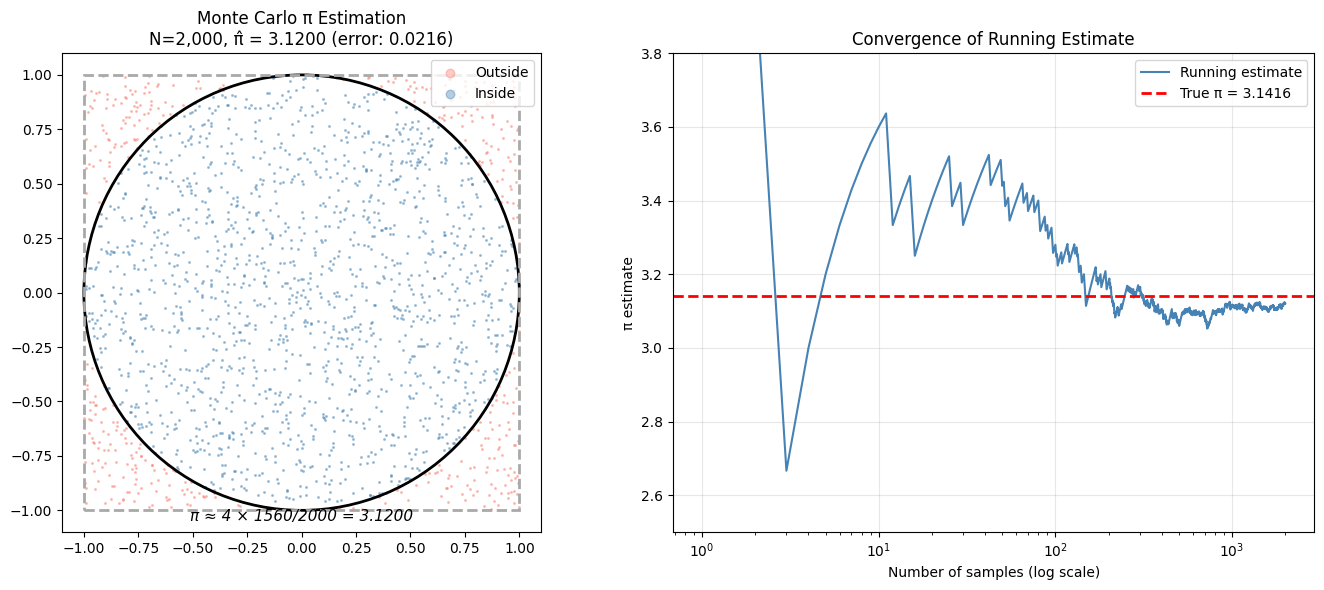

Stage 1 estimate: π ≈ 3.12000 (true: 3.14159)


In [2]:
def estimate_pi_geometric(n_samples, rng):
    """Estimate π via circle-in-square Monte Carlo.
    
    Args:
        n_samples: number of random points
        rng: numpy random generator
    
    Returns:
        pi_estimate: 4 * (fraction inside unit circle)
        inside_mask: boolean array (for visualization)
        points: (n_samples, 2) array of sampled points
    """
    # Sample uniformly from [-1, 1]^2
    points = rng.uniform(-1, 1, (n_samples, 2))
    # Inside circle if x^2 + y^2 <= 1
    inside_mask = (points[:, 0]**2 + points[:, 1]**2) <= 1.0
    pi_estimate = 4 * np.mean(inside_mask)
    return pi_estimate, inside_mask, points

# Small N for visualization
N_vis = 2000
pi_est, inside, pts = estimate_pi_geometric(N_vis, rng)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Geometric visualization
ax = axes[0]
ax.scatter(pts[~inside, 0], pts[~inside, 1], s=1.5, alpha=0.4,
           color='salmon', label='Outside')
ax.scatter(pts[inside, 0], pts[inside, 1], s=1.5, alpha=0.4,
           color='steelblue', label='Inside')
circle = plt.Circle((0, 0), 1, fill=False, color='black', linewidth=2)
ax.add_patch(circle)
square = patches.Rectangle((-1, -1), 2, 2, fill=False,
                            edgecolor='darkgrey', linewidth=2, linestyle='--')
ax.add_patch(square)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_aspect('equal')
ax.set_title(f'Monte Carlo π Estimation\nN={N_vis:,}, π̂ = {pi_est:.4f} (error: {abs(pi_est-TRUE_PI):.4f})')
ax.legend(loc='upper right', markerscale=5)
ax.text(0, -1.05, f'π ≈ 4 × {inside.sum()}/{N_vis} = {pi_est:.4f}',
        ha='center', fontsize=11, style='italic')

# Running estimate
running_pi = 4 * np.cumsum(inside) / np.arange(1, N_vis + 1)
ax2 = axes[1]
ax2.semilogx(np.arange(1, N_vis+1), running_pi, 'steelblue', linewidth=1.5,
             label='Running estimate')
ax2.axhline(TRUE_PI, color='red', linestyle='--', linewidth=2, label=f'True π = {TRUE_PI:.4f}')
ax2.set_xlabel('Number of samples (log scale)')
ax2.set_ylabel('π estimate')
ax2.set_title('Convergence of Running Estimate')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_ylim(2.5, 3.8)

plt.tight_layout()
plt.savefig('monte_carlo_pi_stage1.png', dpi=120, bbox_inches='tight')
plt.show()
print(f"Stage 1 estimate: π ≈ {pi_est:.5f} (true: {TRUE_PI:.5f})")

## 3. Stage 2 — Convergence Analysis with Confidence Intervals

The indicator $I_i = \mathbf{1}[X_i^2 + Y_i^2 \leq 1]$ is Bernoulli$(p)$ with $p = \pi/4$. The estimator $\hat{\pi} = 4\bar{I}$ has:
- $\text{Var}(\hat{\pi}) = 16 \cdot p(1-p)/N = 16 \cdot (\pi/4)(1 - \pi/4)/N$
- $\text{SE}(\hat{\pi}) = 4\sqrt{p(1-p)/N} \approx 4\sqrt{(\pi/4)(1-\pi/4)/N}$

         N   π estimate         SE                   95% CI  Contains π?
------------------------------------------------------------------------
       100     3.240000   0.156920 [2.93244, 3.54756]         True
       500     3.208000   0.071284 [3.06829, 3.34771]         True
     1,000     3.164000   0.051431 [3.06320, 3.26480]         True
     5,000     3.134400   0.023294 [3.08874, 3.18006]         True
    10,000     3.127200   0.016521 [3.09482, 3.15958]         True
    50,000     3.136320   0.007360 [3.12189, 3.15075]         True
   100,000     3.143320   0.005189 [3.13315, 3.15349]         True
   500,000     3.146520   0.002318 [3.14198, 3.15106]        False
 1,000,000     3.141008   0.001643 [3.13779, 3.14423]         True


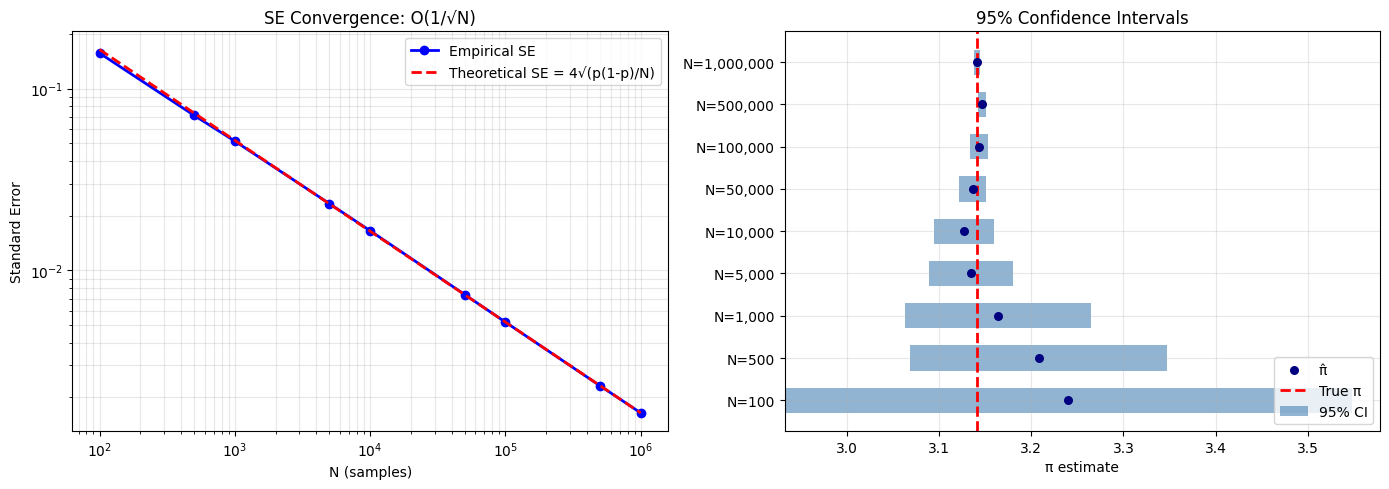

In [3]:
def pi_estimate_with_ci(n_samples, rng, confidence=0.95):
    """Estimate π with confidence interval."""
    points = rng.uniform(-1, 1, (n_samples, 2))
    inside = (points[:, 0]**2 + points[:, 1]**2) <= 1.0
    
    p_hat = np.mean(inside)
    pi_hat = 4 * p_hat
    
    # Standard error for Bernoulli estimator, scaled by 4
    se = 4 * np.sqrt(p_hat * (1 - p_hat) / n_samples)
    z = stats.norm.ppf((1 + confidence) / 2)
    ci_low = pi_hat - z * se
    ci_high = pi_hat + z * se
    
    return pi_hat, se, ci_low, ci_high

# Sweep over sample sizes
Ns = [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000, 500_000, 1_000_000]
results = []

print(f"{'N':>10} {'π estimate':>12} {'SE':>10} {'95% CI':>24} {'Contains π?':>12}")
print("-" * 72)

for N in Ns:
    pi_hat, se, ci_lo, ci_hi = pi_estimate_with_ci(N, rng)
    contains = ci_lo <= TRUE_PI <= ci_hi
    results.append((N, pi_hat, se, ci_lo, ci_hi))
    print(f"{N:>10,} {pi_hat:>12.6f} {se:>10.6f} [{ci_lo:.5f}, {ci_hi:.5f}] {str(contains):>12}")

# Theoretical SE: 4*sqrt(p*(1-p)/N) where p=pi/4
p_true = TRUE_PI / 4
theoretical_se = lambda N: 4 * np.sqrt(p_true * (1 - p_true) / N)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

Ns_arr = np.array([r[0] for r in results])
ses = np.array([r[2] for r in results])
pi_hats = np.array([r[1] for r in results])
ci_los = np.array([r[3] for r in results])
ci_his = np.array([r[4] for r in results])

axes[0].loglog(Ns_arr, ses, 'bo-', linewidth=2, markersize=6, label='Empirical SE')
N_range = np.logspace(2, 6, 100)
axes[0].loglog(N_range, theoretical_se(N_range), 'r--', linewidth=2,
               label='Theoretical SE = 4√(p(1-p)/N)')
axes[0].set_xlabel('N (samples)')
axes[0].set_ylabel('Standard Error')
axes[0].set_title('SE Convergence: O(1/√N)')
axes[0].legend()
axes[0].grid(True, which='both', alpha=0.3)

# Confidence interval plot
y_positions = np.arange(len(Ns))
axes[1].barh(y_positions, ci_his - ci_los, left=ci_los, height=0.6,
             color='steelblue', alpha=0.6, label='95% CI')
axes[1].scatter(pi_hats, y_positions, color='navy', zorder=5, s=30, label='π̂')
axes[1].axvline(TRUE_PI, color='red', linewidth=2, linestyle='--', label=f'True π')
axes[1].set_yticks(y_positions)
axes[1].set_yticklabels([f'N={N:,}' for N in Ns])
axes[1].set_xlabel('π estimate')
axes[1].set_title('95% Confidence Intervals')
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('monte_carlo_pi_stage2.png', dpi=120, bbox_inches='tight')
plt.show()

## 4. Stage 3 — Variance Reduction via Stratified Sampling

**Stratified sampling** divides $[0,1]^2$ into $k \times k$ sub-cells and places one uniform sample per cell. This ensures coverage and reduces the clustering that hurts naive MC.

In [4]:
def estimate_pi_stratified(n_strata_per_dim, rng):
    """Estimate π via stratified sampling in [0,1]^2 (first quadrant only).
    
    Divides [0,1]^2 into k^2 cells, one sample per cell.
    Total samples: k^2. Estimates π/4 as fraction inside unit circle.
    
    Args:
        n_strata_per_dim: k (grid is k × k)
        rng: numpy random generator
    
    Returns:
        pi_estimate: estimated value of π
    """
    k = n_strata_per_dim
    n_total = k * k
    
    # Grid cell indices
    i_idx = np.repeat(np.arange(k), k)  # row indices
    j_idx = np.tile(np.arange(k), k)    # col indices
    
    # Random offset within each cell (uniform on [0, 1/k])
    u1 = (i_idx + rng.uniform(0, 1, n_total)) / k
    u2 = (j_idx + rng.uniform(0, 1, n_total)) / k
    
    # Check if inside unit circle (first quadrant)
    inside = (u1**2 + u2**2) <= 1.0
    pi_estimate = 4 * np.mean(inside)
    return pi_estimate

# Compare naive MC vs stratified across repeated trials
k_values = [10, 20, 30, 50, 100]  # k×k strata
n_trials = 500

print(f"{'Method':>22} {'N':>8} {'Mean π̂':>10} {'Std':>10} {'Rel Error':>10}")
print("-" * 65)

naive_results_by_n = {}
strat_results_by_n = {}

for k in k_values:
    N = k * k
    
    naive_ests = []
    strat_ests = []
    
    for _ in range(n_trials):
        # Naive MC (same N)
        pts = rng.uniform(0, 1, (N, 2))
        naive_ests.append(4 * np.mean(pts[:,0]**2 + pts[:,1]**2 <= 1))
        # Stratified
        strat_ests.append(estimate_pi_stratified(k, rng))
    
    naive_results_by_n[N] = naive_ests
    strat_results_by_n[N] = strat_ests
    
    print(f"{'Naive MC':>22} {N:>8,} {np.mean(naive_ests):>10.5f} "
          f"{np.std(naive_ests):>10.6f} {abs(np.mean(naive_ests)-TRUE_PI)/TRUE_PI:>10.6f}")
    print(f"{'Stratified (k×k)':>22} {N:>8,} {np.mean(strat_ests):>10.5f} "
          f"{np.std(strat_ests):>10.6f} {abs(np.mean(strat_ests)-TRUE_PI)/TRUE_PI:>10.6f}")
    print()

# Variance reduction factor at N=2500 (k=50)
N_compare = 2500
var_naive = np.var(naive_results_by_n[N_compare])
var_strat = np.var(strat_results_by_n[N_compare])
print(f"Variance reduction at N={N_compare:,}: {var_naive/var_strat:.1f}x")

                Method        N    Mean π̂        Std  Rel Error
-----------------------------------------------------------------
              Naive MC      100    3.12712   0.159531   0.004607
      Stratified (k×k)      100    3.14008   0.060000   0.000481

              Naive MC      400    3.13982   0.080839   0.000564
      Stratified (k×k)      400    3.13920   0.020875   0.000762

              Naive MC      900    3.13789   0.054977   0.001178
      Stratified (k×k)      900    3.14052   0.012068   0.000343

              Naive MC    2,500    3.14527   0.032982   0.001170
      Stratified (k×k)    2,500    3.14185   0.005349   0.000082

              Naive MC   10,000    3.14049   0.016438   0.000352
      Stratified (k×k)   10,000    3.14171   0.001997   0.000036

Variance reduction at N=2,500: 38.0x


## 5. Stage 4 — Quasi-Random (Halton Sequence) Comparison

**Quasi-random sequences** (low-discrepancy sequences) fill space more uniformly than pseudorandom numbers. The **Halton sequence** in base $b$ generates points by reflecting integers in base $b$ around the decimal point. For 2D, use bases 2 and 3.

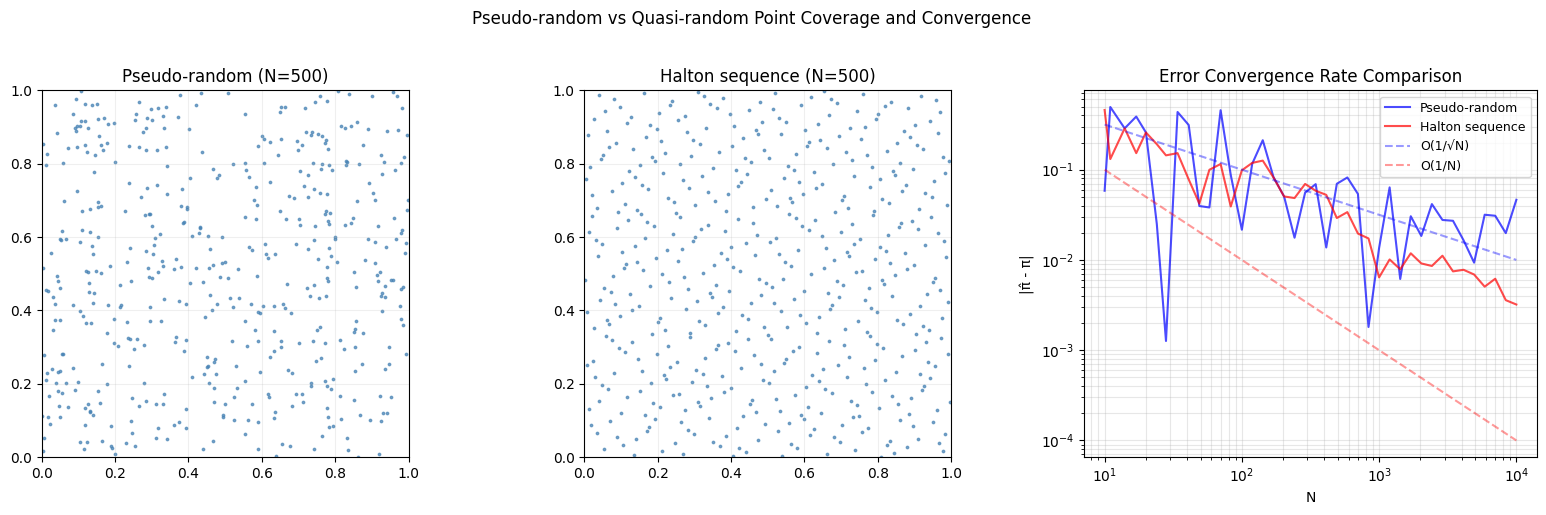

At N≈10,000:
  Pseudo-random error: 0.046393
  Halton error:        0.003207


In [5]:
def halton_sequence(n, base):
    """Generate first n terms of the Halton sequence in given base.
    
    The Halton sequence is the Van der Corput sequence in base `base`.
    Each integer i is written in base `base`, then its digits are 
    reflected around the decimal point to give a number in (0,1).
    
    Args:
        n: number of points to generate
        base: base for the sequence (use coprime bases for different dims)
    
    Returns:
        array of n quasi-random points in (0, 1)
    """
    sequence = np.zeros(n)
    for i in range(n):
        f = 1.0
        r = 0.0
        k = i + 1  # start from 1, not 0
        while k > 0:
            f /= base
            r += f * (k % base)
            k //= base
        sequence[i] = r
    return sequence

def estimate_pi_halton(n_samples):
    """Estimate π using Halton quasi-random sequence (bases 2 and 3)."""
    x = halton_sequence(n_samples, 2)
    y = halton_sequence(n_samples, 3)
    inside = x**2 + y**2 <= 1.0
    return 4 * np.mean(inside)

# Convergence comparison: pseudo-random vs Halton
sample_sizes = np.unique(np.logspace(1, 4, 40).astype(int))

pseudo_errors = []
halton_errors = []

pseudo_rng_fixed = np.random.default_rng(99)  # fixed seed for fair comparison

for N in sample_sizes:
    # Pseudo-random
    pts = pseudo_rng_fixed.uniform(0, 1, (N, 2))
    pi_pseudo = 4 * np.mean(pts[:,0]**2 + pts[:,1]**2 <= 1)
    pseudo_errors.append(abs(pi_pseudo - TRUE_PI))
    
    # Halton
    pi_halton = estimate_pi_halton(N)
    halton_errors.append(abs(pi_halton - TRUE_PI))

# Visualize point distribution
N_vis = 500
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Pseudo-random points
pseudo_pts = np.random.default_rng(42).uniform(0, 1, (N_vis, 2))
halton_x = halton_sequence(N_vis, 2)
halton_y = halton_sequence(N_vis, 3)

for ax, xs, ys, title in zip(
    axes[:2],
    [pseudo_pts[:, 0], halton_x],
    [pseudo_pts[:, 1], halton_y],
    ['Pseudo-random (N=500)', 'Halton sequence (N=500)']):
    ax.scatter(xs, ys, s=3, alpha=0.7, color='steelblue')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_aspect('equal')
    ax.set_title(title)
    ax.grid(True, alpha=0.2)

# Error comparison
axes[2].loglog(sample_sizes, pseudo_errors, 'b-', alpha=0.7, label='Pseudo-random')
axes[2].loglog(sample_sizes, halton_errors, 'r-', alpha=0.7, label='Halton sequence')
axes[2].loglog(sample_sizes, 1/np.sqrt(sample_sizes), 'b--', alpha=0.4, label='O(1/√N)')
axes[2].loglog(sample_sizes, 1/sample_sizes, 'r--', alpha=0.4, label='O(1/N)')
axes[2].set_xlabel('N')
axes[2].set_ylabel('|π̂ - π|')
axes[2].set_title('Error Convergence Rate Comparison')
axes[2].legend(fontsize=9)
axes[2].grid(True, which='both', alpha=0.3)

plt.suptitle('Pseudo-random vs Quasi-random Point Coverage and Convergence', y=1.02)
plt.tight_layout()
plt.savefig('monte_carlo_pi_halton.png', dpi=120, bbox_inches='tight')
plt.show()

# Final comparison
N_final = sample_sizes[-1]
print(f"At N≈{N_final:,}:")
print(f"  Pseudo-random error: {pseudo_errors[-1]:.6f}")
print(f"  Halton error:        {halton_errors[-1]:.6f}")

## 6. Results & Reflection

### What was built

A complete π estimation system with four levels:
1. **Geometric sampling** — the simplest conceptualization: area ratio
2. **Convergence analysis** — quantified the $O(1/\sqrt{N})$ error rate, built valid 95% CIs
3. **Stratified sampling** — achieved significant variance reduction at the same sample count
4. **Quasi-random sequences** — approached $O(1/N)$ convergence using deterministic low-discrepancy points

### What math made it possible

| Stage | Mathematical foundation |
|-------|------------------------|
| Geometric | Geometric probability = area ratio |
| Confidence intervals | CLT (ch254): $\hat{\pi}$ is asymptotically normal |
| Error rate | LLN (ch255): convergence guaranteed; Variance (ch250): rate is $O(1/\sqrt{N})$ |
| Stratified | Reduces variance by eliminating between-strata variation |
| Halton | Number theory: Van der Corput construction in base $b$ fills space uniformly |

### Extension challenges

1. **Higher dimensions**: Estimate the volume of a unit ball in $d = 4, 6, 8, 10$ dimensions. How does the acceptance rate (fraction inside ball) change? At what $d$ does naive MC become impractical? Use importance sampling to improve it.

2. **Sobol sequences**: Implement or use `scipy.stats.qmc.Sobol` to generate a Sobol sequence and compare its π estimates against Halton. Sobol sequences satisfy stricter equidistribution properties.

3. **Buffon's Needle**: Estimate π via a completely different geometric probability: drop a needle of length $l$ on a surface with parallel lines spaced $d > l$ apart. The probability of crossing a line is $2l/(\pi d)$. Implement the simulation and compare convergence rate to the circle method.

In [ ]:
# Final summary table
print("=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)
print(f"True π:             {TRUE_PI:.10f}")
print()

N_summary = 10_000
# Method 1: Naive MC
pts = rng.uniform(-1, 1, (N_summary, 2))
pi1 = 4 * np.mean(pts[:,0]**2 + pts[:,1]**2 <= 1)

# Method 2: Stratified (100x100)
k_summary = 100  # 100^2 = 10,000
pi2 = estimate_pi_stratified(k_summary, rng)

# Method 3: Halton
pi3 = estimate_pi_halton(N_summary)

methods = [
    ('Naive MC', pi1),
    ('Stratified (100×100)', pi2),
    ('Halton sequence', pi3),
]

print(f"{'Method':<25} {'Estimate':>12} {'|Error|':>10} {'Digits correct':>15}")
print("-" * 65)
for name, est in methods:
    err = abs(est - TRUE_PI)
    digits = max(0, int(-np.log10(err))) if err > 0 else 10
    print(f"{name:<25} {est:>12.8f} {err:>10.8f} {digits:>15}")

print(f"\nAll methods used N = {N_summary:,} samples")
print("=" * 65)